# Plots for the paper

In [2]:
from data_import import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from plotting import *

device = 'cuda:0'

df_orig = load_result_table('feeds/phase_diagram_T64').reset_index()
df_orig = df_orig[df_orig['epoch']==499]
figure_dir = figure_dir 

df = df_orig.groupby(CONFIG_COLS).mean(numeric_only=True).reset_index()
df_std = df_orig.groupby(CONFIG_COLS).std(numeric_only=True).reset_index()

                           name     _runtime  _step    _timestamp  \
40              rich-sound-1432  1254.684850  500.0  1.707092e+09   
44           polished-surf-1428  1223.191868  500.0  1.707090e+09   
48            hopeful-surf-1424  1234.753695  500.0  1.707089e+09   
52             sleek-field-1420  1239.446829  500.0  1.707088e+09   
55    resilient-wildflower-1417  1222.627018  500.0  1.707087e+09   
59         usual-armadillo-1413  1234.132040  500.0  1.707086e+09   
63           charmed-disco-1409  1225.352758  500.0  1.707084e+09   
309          stellar-disco-1163  1288.571615  500.0  1.707029e+09   
316         lucky-capybara-1156  1295.309000  500.0  1.707027e+09   
322             absurd-dew-1150  1294.767126  500.0  1.707026e+09   
327            desert-bush-1145  1290.020306  500.0  1.707025e+09   
334           spring-totem-1138  1294.435409  500.0  1.707024e+09   
340           eager-galaxy-1132  1295.440318  500.0  1.707022e+09   
346          scarlet-brook-1126  1

wandb:   1 of 1 files downloaded.  


8 [4, 8, 32]
feeds/phase_diagram_T64/dark-dream-233-model:v0 | val_acc: 81.533


wandb:   1 of 1 files downloaded.  


16 [4, 8, 32]
32 [4, 8, 32]
feeds/phase_diagram_T64/bright-bird-850-model:v0 | val_acc: 97.219


wandb:   1 of 1 files downloaded.  


64 [4, 8, 32]
128 [4, 8, 32]


NameError: name 'figugreydir' is not defined

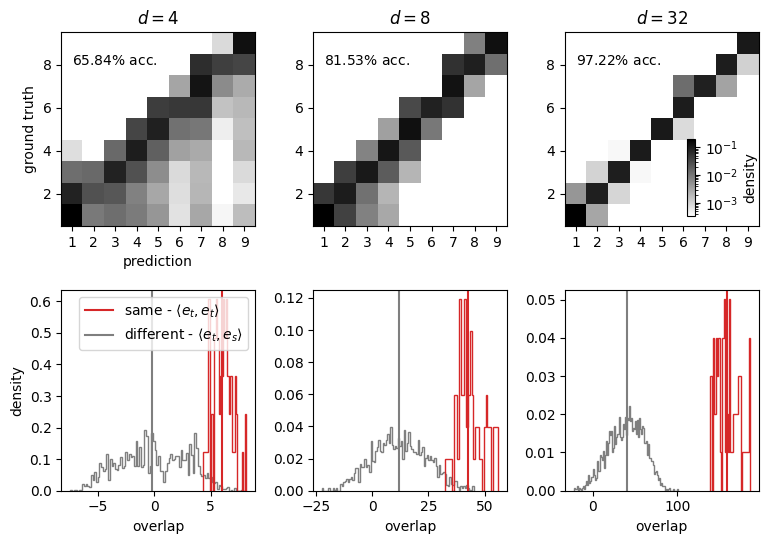

In [7]:
from memory_exp import HistogramDatasetSampleBackward, HistogramDatasetSampleForward, HistogramDatasetSampleBackwardWithBOS
from data_import import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from memory_exp import *
import matplotlib as mpl

bright_distinguishable_colors = plt.cm.tab20.colors
bright_distinguishable_colors = {d: c for c, d in zip(bright_distinguishable_colors,df_orig.model_dim.unique())}

fig, axes = plt.subplots(2,3,figsize=(9,6))
model_config = MODELS['dot+sftm']
k = df_orig
p = 64
T = 64
a = k[(k.attention_input == model_config['attention_input'])
            & (k.no_softmax == model_config['no_softmax']) 
            & (k.dataset_type == model_config['dataset'])
            & (k.p == p)]
print(a)
ds = [4,8,32]
ax_idx_d = {d: i for i, d in enumerate(ds)}
for d, g in a.reset_index().groupby('model_dim'):
    print(d,ds)
    if d not in ds:
        continue
    idx = ax_idx_d[d]
    # find the row with the highest validation accuracy
    g = g.set_index('name').sort_values('val_acc',ascending=True)
    config = g.iloc[0]
    model, word_embeddings = load_model(config)
    dataset_cls = {'forward': HistogramDatasetSampleForward,
                    'backward': HistogramDatasetSampleBackward,
                    'backward_BOS': HistogramDatasetSampleBackwardWithBOS}[config['dataset_type']]
    val_dataset = dataset_cls(config['seq_len'], config['T'], int(0.3 * config['num_samples']))
    train_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    criterion = nn.CrossEntropyLoss()
    n_classes = config['seq_len']+1
    activ = []
    ys = []
    outputs = []
    attn_probs = []
    mixeds = []
    Xs = []
    preds = []
    acc = 0
    val_loss = 0
    counter = word_embeddings.sum(axis=0)/T
    for X, y in train_dataloader:
        X = X.to(device)
        y = y.to(device)
        output = model(X)
        
        # compute accuracy
        pred = output.argmax(axis=-1)
        preds.append(pred.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())
        Xs.append(X.detach().cpu().numpy())

    preds = np.concatenate(preds).flatten()
    ys = np.concatenate(ys).flatten()
    
    confusion = np.zeros((config['seq_len']+1,config['seq_len']+1))
    for i in range(len(ys)):
        confusion[ys[i],preds[i]] += 1

    im = axes[0,idx].imshow(confusion/confusion.sum(), origin='lower', cmap='binary',norm=mpl.colors.LogNorm())
    
    
    axes[0,idx].set_xlim(0.5,config['seq_len']-0.5)
    axes[0,idx].set_ylim(0.5,config['seq_len']-0.5)
    axes[0,idx].set_xticks(range(1, config['seq_len']))
    
    
    
    word_embeddings = word_embeddings #/ torch.norm(word_embeddings,dim=-1).unsqueeze(-1)
    outer = word_embeddings @ word_embeddings.T

    outer = outer.flatten()
    mask = (np.eye(word_embeddings.shape[0]) == 0).flatten()
    axes[1,idx].hist(outer[mask].detach().numpy().flatten(),bins=100,histtype='step',color='tab:grey',density=True)
    axes[1,idx].hist(outer[~mask].detach().numpy().flatten(),bins=30,histtype='step',color='tab:red',density=True)
    axes[1,idx].axvline(outer[mask].median().item(),color='tab:grey')
    axes[1,idx].axvline(outer[~mask].median().item(),color='tab:red')
    axes[1,idx].set_xlabel('overlap')
    
    
    axes[0,idx].text(1, 8, f'${config["val_acc"]:.2f}\%$ acc.')
    axes[0,idx].set_title(f'$d={d}$')
    axes[0,0].set_xlabel('prediction')

axes[0,0].set_ylabel('ground truth')
axes[1,0].set_ylabel('density')
    

    
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = axes[0,-1].inset_axes([0.63,0.05,0.04,0.4])

# adjust the margin between the subplots to be smaller
fig.subplots_adjust(wspace=0.3,hspace=0.3)
# Add a colorbar to the inset_axes
cbar = plt.colorbar(im, cax=cax, label='density')
axes[1,0].plot([],[],label=r'same - $\langle e_t, e_t \rangle$',color='tab:red')
axes[1,0].plot([],[],label=r'different - $\langle e_t, e_s \rangle$',color='tab:grey')
axes[1,0].legend()
plt.savefig(figure_dir / 'changing-d-for-fixed-p-dotsftm_final.pdf',bbox_inches='tight')

In [9]:
from data_import import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from plotting import *

device = 'cuda:0'

df_orig = load_result_table('feeds/phase_diagram_T32').reset_index()
df_orig = df_orig[df_orig['epoch']==499]
figure_dir = figure_dir 

df = df_orig.groupby(CONFIG_COLS).mean(numeric_only=True).reset_index()
df_std = df_orig.groupby(CONFIG_COLS).std(numeric_only=True).reset_index()

                          name     _runtime  _step    _timestamp  \
15        pious-firebrand-5868  1210.235052  500.0  1.719662e+09   
160       comic-butterfly-5723  1251.354375  500.0  1.719628e+09   
325          balmy-deluge-5558  1244.585794  500.0  1.719594e+09   
493           absurd-tree-5390  1233.421285  500.0  1.719560e+09   
658     stellar-firebrand-5225  1241.737381  500.0  1.719526e+09   
...                        ...          ...    ...           ...   
5683  scintillating-dragon-200  1266.862012  500.0  1.707527e+09   
5689         flashing-fish-194  1260.847151  500.0  1.707526e+09   
5695            lunar-lamp-188  1253.546675  500.0  1.707525e+09   
5702       breezy-elevator-181  1246.956320  500.0  1.707524e+09   
5707         ethereal-pine-176  1255.517888  500.0  1.707522e+09   

                 _wandb  epoch  params_count  train_loss    val_acc  val_loss  \
15    {'runtime': 1209}  499.0         461.0    1.865091  26.510734  1.862241   
160   {'runtime': 125

wandb:   1 of 1 files downloaded.  


4 [3, 8, 23]
6 [3, 8, 23]
8 [3, 8, 23]
index                              4497
_runtime                    1214.900959
_step                             500.0
_timestamp            1707773454.940428
_wandb                {'runtime': 1214}
epoch                             499.0
params_count                     1035.0
train_loss                     0.370365
val_acc                       87.672874
val_loss                       0.384336
T                                    32
p                                    32
lr                                0.001
seq_len                              10
n_epochs                            500
run_name                           None
model_dim                             8
optimizer                          Adam
batch_size                           32
no_softmax                        False
num_samples                       10000
dataset_type                   backward
project_name          phase_diagram_T32
attention_input                only_sem
o

wandb:   1 of 1 files downloaded.  


11 [3, 8, 23]
16 [3, 8, 23]
23 [3, 8, 23]
index                              2028
_runtime                    2045.567745
_step                             500.0
_timestamp             1709744091.65683
_wandb                {'runtime': 2048}
epoch                             499.0
params_count                     2925.0
train_loss                      0.07579
val_acc                       98.279827
val_loss                       0.082608
T                                    32
p                                    32
lr                                0.001
seq_len                              10
n_epochs                            500
run_name                           None
model_dim                            23
optimizer                          Adam
batch_size                           32
no_softmax                        False
num_samples                       10000
dataset_type                   backward
project_name          phase_diagram_T32
attention_input                only_se

wandb:   1 of 1 files downloaded.  


32 [3, 8, 23]
45 [3, 8, 23]
64 [3, 8, 23]
91 [3, 8, 23]
128 [3, 8, 23]


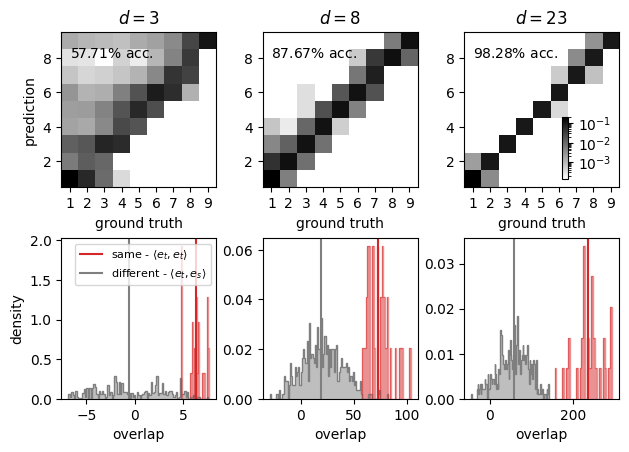

In [27]:
from memory_exp import HistogramDatasetSampleBackward, HistogramDatasetSampleForward, HistogramDatasetSampleBackwardWithBOS
from data_import import *
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from memory_exp import *
import matplotlib as mpl

bright_distinguishable_colors = plt.cm.tab20.colors
bright_distinguishable_colors = {d: c for c, d in zip(bright_distinguishable_colors,df_orig.model_dim.unique())}

fig, axes = plt.subplots(2,3,figsize=(9*0.8,6*0.8))
model_config = MODELS['dot+sftm']
k = df_orig
p = 32
T = 32
a = k[(k.attention_input == model_config['attention_input'])
            & (k.no_softmax == model_config['no_softmax']) 
            & (k.dataset_type == model_config['dataset'])
            & (k.p == p)]
print(a)
ds = [3,8,23]
ax_idx_d = {d: i for i, d in enumerate(ds)}
for d, g in a.reset_index().groupby('model_dim'):
    print(d,ds)
    if d not in ds:
        continue
    idx = ax_idx_d[d]
    # find the row with the highest validation accuracy
    g = g.set_index('name').sort_values('val_acc',ascending=True)
    config = g.iloc[0]
    print(config)
    model, word_embeddings = load_model(config)
    dataset_cls = {'forward': HistogramDatasetSampleForward,
                    'backward': HistogramDatasetSampleBackward,
                    'backward_BOS': HistogramDatasetSampleBackwardWithBOS}[config['dataset_type']]
    val_dataset = dataset_cls(config['seq_len'], config['T'], int(0.3 * config['num_samples']))
    train_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    criterion = nn.CrossEntropyLoss()
    n_classes = config['seq_len']+1
    activ = []
    ys = []
    outputs = []
    attn_probs = []
    mixeds = []
    Xs = []
    preds = []
    acc = 0
    val_loss = 0
    counter = word_embeddings.sum(axis=0)/T
    for X, y in train_dataloader:
        X = X.to(device)
        y = y.to(device)
        output = model(X)
        
        # compute accuracy
        pred = output.argmax(axis=-1)
        preds.append(pred.detach().cpu().numpy())
        ys.append(y.detach().cpu().numpy())
        Xs.append(X.detach().cpu().numpy())

    preds = np.concatenate(preds).flatten()
    ys = np.concatenate(ys).flatten()
    
    confusion = np.zeros((config['seq_len']+1,config['seq_len']+1))
    for i in range(len(ys)):
        confusion[preds[i],ys[i]] += 1

    im = axes[0,idx].imshow(confusion/confusion.sum(), origin='lower', cmap='binary',norm=mpl.colors.LogNorm())
    
    
    axes[0,idx].set_xlim(0.5,config['seq_len']-0.5)
    axes[0,idx].set_ylim(0.5,config['seq_len']-0.5)
    axes[0,idx].set_xticks(range(1, config['seq_len']))
    
    
    
    word_embeddings = word_embeddings #/ torch.norm(word_embeddings,dim=-1).unsqueeze(-1)
    outer = word_embeddings @ word_embeddings.T

    outer = outer.flatten()
    mask = (np.eye(word_embeddings.shape[0]) == 0).flatten()
    axes[1,idx].hist(outer[mask].detach().numpy().flatten(),bins=100,alpha=0.5,color='tab:grey',density=True)
    axes[1,idx].hist(outer[~mask].detach().numpy().flatten(),bins=30,alpha=0.5,color='tab:red',density=True)
    axes[1,idx].hist(outer[mask].detach().numpy().flatten(),bins=100,histtype='step',color='tab:grey',density=True)
    axes[1,idx].hist(outer[~mask].detach().numpy().flatten(),bins=30,histtype='step',alpha=0.5,color='tab:red',density=True)
    axes[1,idx].axvline(outer[mask].median().item(),color='tab:grey')
    axes[1,idx].axvline(outer[~mask].median().item(),color='tab:red')
    axes[1,idx].set_xlabel('overlap')
    
    
    axes[0,idx].text(1, 8, f'${config["val_acc"]:.2f}\%$ acc.')
    axes[0,idx].set_title(f'$d={d}$')
    axes[0,idx].set_xlabel('ground truth')

axes[0,0].set_ylabel('prediction')
axes[1,0].set_ylabel('density')
    

    
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
cax = axes[0,-1].inset_axes([0.63,0.05,0.04,0.4])

# adjust the margin between the subplots to be smaller
fig.subplots_adjust(wspace=0.3,hspace=0.3)
# Add a colorbar to the inset_axes
cbar = plt.colorbar(im, cax=cax)
axes[1,0].plot([],[],label=r'same - $\langle e_t, e_t \rangle$',color='tab:red')
axes[1,0].plot([],[],label=r'different - $\langle e_t, e_s \rangle$',color='tab:grey')
axes[1,0].legend(fontsize=8)
plt.savefig(figure_dir / 'changing-d-for-fixed-p-dotsftm_T32.pdf',bbox_inches='tight')